### Necessary Imports

In [175]:
## Needed to extract the data from the .eml file and write it on the csv
import os
import csv
from email import policy
from email.parser import BytesParser
import re

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import re

#To use beatiful soup
from bs4 import BeautifulSoup

#To use unicode
import unicodedata
import chardet

#For dividing the dataset 
from sklearn.model_selection import train_test_split

#For plotting
import seaborn as sns
import matplotlib.pyplot as plt

#For the hot encoding
from sklearn.preprocessing import OneHotEncoder

#For model training
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#For model evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, accuracy_score

 
#For NB Classifier (Content)
import math
import nltk
import numpy as np
import polars as pl
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

#For LR Classifier (Content)
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from jax import grad
import jax.numpy as jnp

from sklearn.metrics import matthews_corrcoef
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

#To be able to save the models
import pickle 
import joblib 




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bogal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bogal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bogal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bogal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\bogal\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## Gathering the Data from each spam email for the dataset with only the headers

### Helper Functions

In [176]:
def extract_certifying_authorities(auth_results):
    authorities = []
    for result in auth_results:
        # Regex to capture authority names from authentication results (e.g., "spf=pass (domain.com)")
        match = re.search(r'(\w+)=\w+', result)
        if match:
            authority = match.group(1)  # Capture the authentication method (e.g., spf, dkim, dmarc)
            authorities.append(authority)
    return authorities

In [177]:
# Get folder path from user input
#folder_path = input("Enter the folder path containing spam .eml files: ")
folder_path = "spam_emails"
output_csv = "emails_headers_dataset.csv"  # Output CSV file name

# Open the CSV file for writing
with open(output_csv, mode='w', newline='', encoding='utf-8') as csv_file:
    csv_writer = csv.writer(csv_file)

    # Write the header row
    csv_writer.writerow([
        'ham or spam',
        'from_header',
        'is_no_reply',
        'reply_to_header',
        'reply_is_same_as_from',
        'content_type_header',
        'certifying_authorities'
    ])

    # List all files in the folder
    for file_name in os.listdir(folder_path):
        # Process only .eml files
        if file_name.endswith('.eml'):
            eml_file = os.path.join(folder_path, file_name)
            #print(f"Processing file: {eml_file}")

            try:
                # Open and parse the .eml file
                with open(eml_file, 'rb') as fp:
                    msg = BytesParser(policy=policy.default).parse(fp)

                # Access headers
                from_header = msg['from']
                reply_to_header = msg['reply-to']
                content_type_header = msg['content-type']
                
                # Extract only the type without additional parameters
                content_type_header = content_type_header.split(";")[0]

                received_header = msg.get_all('received', [])
                authenticated_results_header = msg.get_all('authentication-results', [])

                # Calculate additional columns
                reply_is_same_as_from = (
                    (from_header and reply_to_header) and (from_header.strip().lower() == reply_to_header.strip().lower())
                )

                certifying_authorities = "; ".join(extract_certifying_authorities(authenticated_results_header))


                is_no_reply = any(substring in from_header.lower() for substring in ["noreply", "no-reply"]) if from_header else False


                # Write the row to the CSV file
                csv_writer.writerow([
                    'spam',
                    from_header,
                    is_no_reply,
                    reply_to_header,
                    reply_is_same_as_from,
                    content_type_header,
                    certifying_authorities
                ])

            except Exception as e:
                print(f"An error occurred while processing {eml_file}: {e}")

#print(f"Data from .eml files has been saved to {output_csv}")



Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None


## Gathering the Data from each ham email for the dataset with only the headers

In [ ]:
# Get folder path from user input
#folder_path = input("Enter the folder path containing ham .eml files: ")
folder_path = "ham_emails"

# Open the CSV file for writing
with open(output_csv, mode='a', newline='', encoding='utf-8') as csv_file:
    csv_writer = csv.writer(csv_file)

    # List all files in the folder
    for file_name in os.listdir(folder_path):
        # Process only .eml files
        if file_name.endswith('.eml'):
            eml_file = os.path.join(folder_path, file_name)
            #print(f"Processing file: {eml_file}")

            try:
                # Open and parse the .eml file
                with open(eml_file, 'rb') as fp:
                    msg = BytesParser(policy=policy.default).parse(fp)

                # Access headers
                from_header = msg['from']
                reply_to_header = msg['reply-to']
                content_type_header = msg['content-type']
                
                # Extract only the type without additional parameters
                content_type_header = content_type_header.split(";")[0]

                received_header = msg.get_all('received', [])
                authenticated_results_header = msg.get_all('authentication-results', [])

                # Calculate additional columns
                reply_is_same_as_from = (
                    (from_header and reply_to_header) and (from_header.strip().lower() == reply_to_header.strip().lower())
                )

                #shortened_relays = "; ".join(extract_server_names(received_header))

                certifying_authorities = "; ".join(extract_certifying_authorities(authenticated_results_header))


                is_no_reply = any(substring in from_header.lower() for substring in ["noreply", "no-reply"]) if from_header else False


                # Write the row to the CSV file
                csv_writer.writerow([
                    'ham',
                    from_header,
                    is_no_reply,
                    reply_to_header,
                    reply_is_same_as_from,
                    content_type_header,
                    # content_header,
                    #shortened_relays,
                    #"; ".join(authenticated_results_header),
                    certifying_authorities
                ])

            except Exception as e:
                print(f"An error occurred while processing {eml_file}: {e}")

#print(f"Data from .eml files has been saved to {output_csv}")



Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: decode() argument 'encoding' must be str, not None
Error decoding payload: d

## Gathering the email contents from each spam email for the dataset with only the content

### Helper Functions

In [179]:
def clean_html(html):
    soup = BeautifulSoup(html, 'html.parser')
    return soup.get_text()

def fix_misencoded_text(text):
    try:
        # Detect encoding
        detected = chardet.detect(text.encode('utf-8', errors='ignore'))
        encoding = detected['encoding'] if detected['confidence'] > 0.7 else 'utf-8'
        # Decode and re-encode properly
        fixed_text = text.encode('latin1').decode('utf-8')  # Adjust encodings as needed
        return unicodedata.normalize('NFKD', fixed_text)
    except Exception:
        # If decoding fails, return the original text
        return text

def extract_content_from_multipart(msg):
    content = ''
    if msg.is_multipart():
        html_part = None
        text_part = None

        for part in msg.iter_parts():
            content_type = part.get_content_type().lower()
            charset = 'utf-8'

            if 'html' in content_type:
                html_part = part
            elif 'plain' in content_type:
                text_part = part

        if html_part:
            try:
                content = clean_html(html_part.get_payload(decode=True).decode(charset, errors='replace'))
            except Exception as e:
                print(f"Error decoding HTML part: {e}")
        elif text_part:
            try:
                content = text_part.get_payload(decode=True).decode(charset, errors='replace')
            except Exception as e:
                print(f"Error decoding text part: {e}")
    else:
        try:
            charset = msg.get_content_charset() or 'utf-8'
            content = msg.get_payload(decode=True).decode(charset, errors='ignore')
            content = fix_misencoded_text(content)  # Fix misencoded text
        except Exception as e:
            print(f"Error decoding simple payload: {e}")

    return content

In [180]:
#folder_path = input("Enter the folder path containing spam .eml files: ")
folder_path = "spam_emails"
output_csv = "emails_content_dataset.csv"  # Output CSV file name

with open(output_csv, mode='w', newline='', encoding='utf-8') as csv_file:
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow([
        'ham or spam',
        'content'
    ])
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.eml'):
            eml_file = os.path.join(folder_path, file_name)
            print(f"Processing file: {eml_file}")

            try:
                with open(eml_file, 'rb') as fp:
                    msg = BytesParser(policy=policy.default).parse(fp)

                content_type_header = msg['content-type']

                content = fix_misencoded_text(extract_content_from_multipart(msg))

                if content:
                    csv_writer.writerow([
                        'spam',
                        content
                    ])
            except Exception as e:
                print(f"An error occurred while processing {eml_file}: {e}")

Processing file: spam_emails\(sem assunto).eml.eml
Processing file: spam_emails\(sem assunto).eml[1].eml
Processing file: spam_emails\-10% la monitoare Dell & Alienware. Pana la -23% la PC Gaming..eml[1].eml
Processing file: spam_emails\-25% em TUDO - Só por 48h, só para ti! 🤫 .eml[1].eml
Processing file: spam_emails\10_ Off_ Nova Coleção 👀.eml.eml
Processing file: spam_emails\50% de desconto EM TUDO esta semana! 😱🍕.eml[1](1).eml
Processing file: spam_emails\50% de desconto EM TUDO esta semana! 😱🍕.eml[1].eml
Processing file: spam_emails\50% de desconto no New Balance Kaiha 👟🖤.eml[1].eml
Processing file: spam_emails\50% para novos clientes_ Só Black Friday! 🎁.eml[1].eml
Processing file: spam_emails\A Black Friday já começou com 50% 😱.eml[1][1].eml
Processing file: spam_emails\A Black Friday já começou com 50% 😱.eml[2].eml
Processing file: spam_emails\A Cyber Monday chegou com promoções até -40%.eml[1].eml
Processing file: spam_emails\A New Dawn - Illuvium_ Overworld MMO-Lite.eml[1].eml


## Gathering the email contents from each ham email for the dataset with only the content

In [181]:
#folder_path = input("Enter the folder path containing ham .eml files: ")
folder_path = "ham_emails"

with open(output_csv, mode='a', newline='', encoding='utf-8') as csv_file:
    csv_writer = csv.writer(csv_file)
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.eml'):
            eml_file = os.path.join(folder_path, file_name)
            print(f"Processing file: {eml_file}")

            try:
                with open(eml_file, 'rb') as fp:
                    msg = BytesParser(policy=policy.default).parse(fp)

                content_type_header = msg['content-type']

                content = fix_misencoded_text(extract_content_from_multipart(msg))

                if content:
                    csv_writer.writerow([
                        'ham',
                        content
                    ])
            except Exception as e:
                print(f"An error occurred while processing {eml_file}: {e}")

Processing file: ham_emails\95% Bilhetes Vendidos - Começa 2025 em Grande!.eml[1].eml
Processing file: ham_emails\A video game sale to whet your appetite before Black Friday.eml[1].eml
Processing file: ham_emails\Acaba Hoje a Promoção Exclusiva do IGNITE 🔔.eml[1].eml
Processing file: ham_emails\Agil.eml[1].eml
Processing file: ham_emails\Agradecimento do BA-Porto da 58º Campanha.eml[1].eml
Processing file: ham_emails\AI and machine learning made easy for all.eml[1].eml
Processing file: ham_emails\Airpods Encontrados.eml
Processing file: ham_emails\Alojamento guimaraes.eml
Processing file: ham_emails\Apresentação.eml
Processing file: ham_emails\Arrenda-se quarto.eml
Processing file: ham_emails\As 2 Escolhas Que Todos Temos de Fazer.eml[1].eml
Processing file: ham_emails\Ativa o Teu Futuro! _ Programa Trilhos.eml[1].eml
Processing file: ham_emails\Autoridade Tributária e Aduaneira - Processo nº 2291250.eml
Processing file: ham_emails\Autoridade Tributária e Aduaneira - Processo.eml
Proce

In [182]:
df = pd.read_csv('emails_headers_dataset.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533 entries, 0 to 532
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ham or spam             533 non-null    object
 1   from_header             533 non-null    object
 2   is_no_reply             533 non-null    bool  
 3   reply_to_header         326 non-null    object
 4   reply_is_same_as_from   326 non-null    object
 5   content_type_header     533 non-null    object
 6   certifying_authorities  509 non-null    object
dtypes: bool(1), object(6)
memory usage: 25.6+ KB


C:\Users\bogal\AppData\Local\Temp\ipykernel_23160\423582440.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x="ham or spam", palette="Dark2", edgecolor="black", linewidth=1.5)


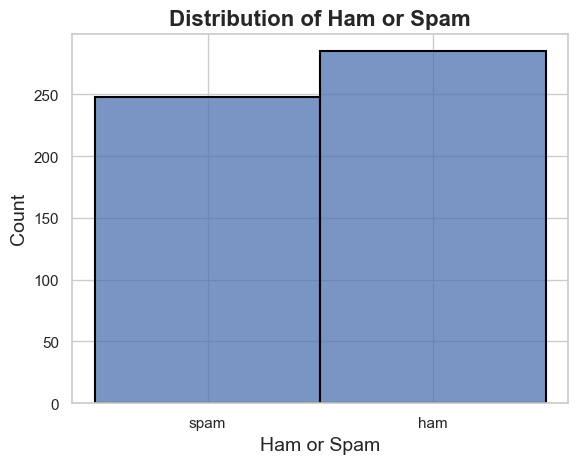

In [183]:
sns.set(style="whitegrid")

df['ham or spam'] = df['ham or spam'].astype(str)

# Create the histogram
sns.histplot(data=df, x="ham or spam", palette="Dark2", edgecolor="black", linewidth=1.5)

# Add titles and labels
plt.title("Distribution of Ham or Spam", fontsize=16, fontweight='bold')
plt.xlabel("Ham or Spam", fontsize=14)
plt.ylabel("Count", fontsize=14)

# Show the plot
plt.show()


## Cleaning the Data of the Headers Dataset  
In this case what we done has deal with missing values

In [184]:
headers_dataset = pd.read_csv('emails_headers_dataset.csv')

def clean_duplicates_in_cell(value):
    if pd.isnull(value):  # Handle NaN values
        return value
    # Split the content by ';', strip whitespace, deduplicate, and recombine
    items = [item.strip() for item in value.split(';')]  # Split and clean each item
    unique_items = list(dict.fromkeys(items))  # Maintain order and remove duplicates
    return ';'.join(unique_items)

headers_dataset['certifying_authorities'] = headers_dataset['certifying_authorities'].apply(clean_duplicates_in_cell)

#Replace missing values with "unknown"
headers_dataset['reply_to_header'].fillna('unknown', inplace=True)

#Replace missing values with False
headers_dataset['reply_is_same_as_from'].fillna(False, inplace=True)

#Replace missing values with "missing"
headers_dataset['certifying_authorities'].fillna('missing', inplace=True)

#Strip leading/trailing spaces and lowercase all object columns
headers_dataset = headers_dataset.applymap(lambda x: x.strip() if isinstance(x, str) else x)
headers_dataset = headers_dataset.applymap(lambda x: x.lower() if isinstance(x, str) else x)


##cleaned_file_path = 'cleaned_emails_headers_dataset.csv'
##headers_dataset.to_csv(cleaned_file_path, index=False)


C:\Users\bogal\AppData\Local\Temp\ipykernel_23160\1233164755.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  headers_dataset = headers_dataset.applymap(lambda x: x.strip() if isinstance(x, str) else x)
C:\Users\bogal\AppData\Local\Temp\ipykernel_23160\1233164755.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  headers_dataset = headers_dataset.applymap(lambda x: x.lower() if isinstance(x, str) else x)


## Cleaning the Data of the Content Dataset  
In this case what we done has deal with the special characters and removing duplicates

In [185]:
content_dataset = pd.read_csv('emails_content_dataset.csv')

#Remove Non-Text Characters
def clean_text(text):
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces/newlines with a single space
    text = re.sub(r'[^\w\s,.!?-]', '', text)  # Keep only meaningful characters

    return text.strip()

content_dataset['content'] = content_dataset['content'].apply(clean_text)

#Remove Duplicates
content_dataset = content_dataset.drop_duplicates(subset=['content'])


## Encoding the Headers

In [186]:
fields_to_encode = ["ham or spam","from_header","reply_to_header","is_no_reply", "reply_is_same_as_from", "content_type_header", "certifying_authorities"]
encoder = OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse=False)

#Apply encoding to the selected fields
encoded_recommended_headers = encoder.fit_transform(headers_dataset[fields_to_encode])

#Create a DataFrame with the encoded values
encoded_columns = encoder.get_feature_names_out(fields_to_encode)
encoded_df = pd.DataFrame(encoded_recommended_headers, columns=encoded_columns)

#Combine the encoded columns with the rest of the dataset (dropping original encoded fields)
processed_headers = pd.concat(
    [
        headers_dataset.drop(columns=fields_to_encode).reset_index(drop=True),
        encoded_df.reset_index(drop=True),
    ],
    axis=1,
)

C:\Users\bogal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## Spliting data into test and training for Headers dataset

In [187]:
X = headers_dataset.drop(columns=['ham or spam'])  # All columns except the target variable
y = headers_dataset['ham or spam'].map({'spam': 1, 'ham': 0})  # Convert labels to numeric (spam=1, ham=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Identify non-numeric columns
non_numeric_columns = X.select_dtypes(include=['object']).columns

#Drop non-numeric columns
X = X.drop(columns=non_numeric_columns)

#Convert boolean columns to integers (if any exist)
X = X.astype(float)

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Evaluation for Headers dataset

#### Using Random Forest 

In [188]:
#Train a Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#Evaluate the Model
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1-Score: {f1_score(y_test, y_pred)}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred)}")

print(classification_report(y_test, y_pred))


Accuracy: 0.4953271028037383
Precision: 0.7142857142857143
Recall: 0.08771929824561403
F1-Score: 0.15625
AUC-ROC: 0.523859649122807
              precision    recall  f1-score   support

           0       0.48      0.96      0.64        50
           1       0.71      0.09      0.16        57

    accuracy                           0.50       107
   macro avg       0.60      0.52      0.40       107
weighted avg       0.60      0.50      0.38       107



#### Using SVM

In [189]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, svm_pred)}")
print(f"Precision: {precision_score(y_test, svm_pred)}")
print(f"Recall: {recall_score(y_test, svm_pred)}")
print(f"F1-Score: {f1_score(y_test, svm_pred)}")
print(f"AUC-ROC: {roc_auc_score(y_test, svm_pred)}")
print(classification_report(y_test, svm_pred))

Accuracy: 0.4953271028037383
Precision: 0.7142857142857143
Recall: 0.08771929824561403
F1-Score: 0.15625
AUC-ROC: 0.523859649122807
              precision    recall  f1-score   support

           0       0.48      0.96      0.64        50
           1       0.71      0.09      0.16        57

    accuracy                           0.50       107
   macro avg       0.60      0.52      0.40       107
weighted avg       0.60      0.50      0.38       107



#### Using Logistic Regresion

In [190]:
logistic_model = LogisticRegression(random_state=42, max_iter=500)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print(f"Accuracy: {accuracy_score(y_test, logistic_pred)}")
print(f"Precision: {precision_score(y_test, logistic_pred)}")
print(f"Recall: {recall_score(y_test, logistic_pred)}")
print(f"F1-Score: {f1_score(y_test, logistic_pred)}")
print(f"AUC-ROC: {roc_auc_score(y_test, logistic_pred)}")
print(classification_report(y_test, logistic_pred))

# Save the model as a pickle in a file 
joblib.dump(logistic_model, 'headers_model.pkl') 
  

Accuracy: 0.4953271028037383
Precision: 0.7142857142857143
Recall: 0.08771929824561403
F1-Score: 0.15625
AUC-ROC: 0.523859649122807
              precision    recall  f1-score   support

           0       0.48      0.96      0.64        50
           1       0.71      0.09      0.16        57

    accuracy                           0.50       107
   macro avg       0.60      0.52      0.40       107
weighted avg       0.60      0.50      0.38       107



['headers_model.pkl']

#### Using K Neigbhors

In [191]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, knn_pred)}")
print(f"Precision: {precision_score(y_test, knn_pred)}")
print(f"Recall: {recall_score(y_test, knn_pred)}")
print(f"F1-Score: {f1_score(y_test, knn_pred)}")
print(f"AUC-ROC: {roc_auc_score(y_test, knn_pred)}")
print(classification_report(y_test, knn_pred))

Accuracy: 0.4953271028037383
Precision: 0.7142857142857143
Recall: 0.08771929824561403
F1-Score: 0.15625
AUC-ROC: 0.523859649122807
              precision    recall  f1-score   support

           0       0.48      0.96      0.64        50
           1       0.71      0.09      0.16        57

    accuracy                           0.50       107
   macro avg       0.60      0.52      0.40       107
weighted avg       0.60      0.50      0.38       107



In [192]:
dataset = [(row['ham or spam'], row['content']) for _, row in content_dataset.iterrows()]
idx = int(len(dataset)*.8)
dataset_train = dataset[0: idx]
dataset_test = dataset[idx:]

## Model Training and Evaluation for Content dataset

#### Helper Functions for the Nayve Bays Class

In [193]:
def np_log_fit(x, y):
    a, b = np.polyfit(np.log(x), y, 1)
    return a, b

def np_exp_fit(x, y):
    a, b = np.polyfit(x, np.log(y), 1, w=np.sqrt(y))
    return a, np.exp(b)

def plot_vocab(vocab):
    words = [word for word,_ in vocab]
    probs = [prob for _,prob in vocab]
    x_pos = np.arange(len(words)) 

    #slope, intercept = np.polyfit(x_pos, probs, 1)
    #trendline = intercept + (slope * x_pos)

    a, b = np_exp_fit(x_pos, probs)
    trendline_exp = b*np.exp(a*x_pos)

    #plt.plot(x_pos, trendline, color='red', linestyle='--')
    plt.plot(x_pos, trendline_exp, color='green', linestyle='--')
    plt.bar(x_pos, probs,align='center')
    plt.xticks(x_pos, words) 
    plt.ylabel('Probs')
    plt.xticks(rotation=45, ha='right')
    plt.show()

### Nayve Bays Class

In [194]:
class NB:
    def __init__(self, k=1, m=2):
        self.k = k
        self.m = m
        self.lemmatizer = WordNetLemmatizer()
    
    def _nltk_pos_tagger(self, nltk_tag):
        if nltk_tag.startswith('J'):
            return nltk.corpus.wordnet.ADJ
        elif nltk_tag.startswith('V'):
            return nltk.corpus.wordnet.VERB
        elif nltk_tag.startswith('N'):
            return nltk.corpus.wordnet.NOUN
        elif nltk_tag.startswith('R'):
            return nltk.corpus.wordnet.ADV
        else:          
            return None
    
    def _nltk_pos_lemmatizer(self, token, tag):
        if tag is None:
            return self.lemmatizer.lemmatize(token)
        else:        
            return self.lemmatizer.lemmatize(token, tag)

    def _vocab(self, samples):
        vocab = [token for sample in samples for token in sample]
        #print(f'{samples}/{vocab}')
        return list(set(vocab))

    def _compute_likelihood(self, samples):
        likelihood = {}
        vocab = self._vocab(samples)
        
        for w in vocab:
            count = 0
            for sentence in samples:
                if w in sentence:
                    #print(w+":", sentence)
                    count += 1
            #print(f"Number of ham emails with the word '{w}': {count}")
            #prob = (count + self.k)/(len(samples) + 2.0*self.k) # smoothing
            #print(f"Probability of the word '{w}': {prob} ")
            likelihood[w.lower()] = count
        return likelihood
    
    def _p_word_spam(self, token):
        return (self.k + self.likelihood_spam.get(token, 0.0)) / ((2.0 * self.k) + self.num_spam_messages)

    def _p_word_ham(self, token):
        return (self.k + self.likelihood_ham.get(token, 0.0)) / ((2.0 * self.k) + self.num_ham_messages)

    def get_spam_vocab(self, n=10):
        vocab = []
        for k in self.likelihood_spam:
            prob = self._p_word_spam(k)
            vocab.append((k, prob))
        # Sort the vocab
        vocab.sort(reverse=True, key=lambda e: (e[1], e[0]))
        # Return
        return vocab[:min(n, len(vocab))]
    
    def get_ham_vocab(self, n=10):
        vocab = []
        for k in self.likelihood_spam:
            prob = self._p_word_ham(k)
            vocab.append((k, prob))
        # Sort the vocab
        vocab.sort(reverse=True, key=lambda e: (e[1], e[0]))
        # Return
        return vocab[:min(n, len(vocab))] 

    def train(self, dataset):
        # compute priors
        dataset_total = len(dataset)
        print()

        spam_samples = [txt for txt, label in dataset if label == 'spam']
        ham_samples = [txt for txt, label in dataset if label == 'ham']

        print(f'{spam_samples}')
        print(f'{ham_samples}')

        self.ps = len(spam_samples) / dataset_total
        self.ph = len(ham_samples) / dataset_total

        #print(f'{self.ps} {self.ph}')

        # Pre-process text
        ## Tokenize the text and get the POS (Part Of Speech)
        spam_samples_nltk_tagged = [nltk.pos_tag(nltk.word_tokenize(sample)) for sample in spam_samples]
        spam_samples = [[(t[0], self._nltk_pos_tagger(t[1])) for t in tokens] for tokens in spam_samples_nltk_tagged]
        ham_samples_nltk_tagged = [nltk.pos_tag(nltk.word_tokenize(sample)) for sample in ham_samples]
        ham_samples = [[(t[0], self._nltk_pos_tagger(t[1])) for t in tokens] for tokens in ham_samples_nltk_tagged]

        ## Lemmatization with POS
        spam_samples = [[self._nltk_pos_lemmatizer(w,t).lower() for w,t in tokens] for tokens in spam_samples]
        ham_samples = [[self._nltk_pos_lemmatizer(w,t).lower()  for w,t in tokens] for tokens in ham_samples]
        
        ## Filter out small words
        spam_samples = [[w for w in tokens if len(w) > self.m] for tokens in spam_samples]
        ham_samples =  [[w for w in tokens if len(w) > self.m] for tokens in ham_samples]

        #print(f'{spam_samples}')
        #print(f'{ham_samples}')

        # compute_likelihood
        self.likelihood_spam = self._compute_likelihood(spam_samples)
        self.num_spam_messages = len(spam_samples)
        self.likelihood_ham = self._compute_likelihood(ham_samples)
        self.num_ham_messages = len(ham_samples)

        #print(f'{self.likelihood_spam}')
        #print(f'{self.likelihood_ham}')
    
    def predict(self, txt):
        # Pre-process text (similar to the train)
        if txt is not None:
            tokens = nltk.pos_tag(nltk.word_tokenize(txt))
            tokens = [(t[0], self._nltk_pos_tagger(t[1])) for t in tokens]
            tokens = [self._nltk_pos_lemmatizer(w, t).lower() for w,t in tokens]
            tokens = [w for w in tokens if len(w) > self.m]
            #tokens = [self.lemmatizer.lemmatize(w).lower() for w in tokens if len(self.lemmatizer.lemmatize(w)) > 2]
        else:
            tokens = []
        #print(tokens)

        log_p_spam = 0.0
        log_p_ham = 0.0

        for t in tokens:
            log_p_spam += math.log(self._p_word_spam(t))
            log_p_ham += math.log(self._p_word_ham(t))
        

        prob_spam = (math.exp(log_p_spam) * self.ps) / (math.exp(log_p_spam) * self.ps + math.exp(log_p_ham) * self.ph)
        if prob_spam >= 0.5:
            return 'spam', prob_spam
        else:
            return 'ham', prob_spam

### Training the model with the Nayve Bays Class

In [195]:
# Convert the dataset to a list of tuples (content, label) as expected by the NB class
content_dataset_tuple = list(zip(content_dataset['content'], content_dataset['ham or spam']))

clf = NB()
clf.train(content_dataset_tuple)


['-- Sou Maria Elisabeth Schaeffler, empresária alemã, investidora e CEO do Grupo Schaeffler. Sou um dos proprietários do Grupo Schaeffler. Estou a doar 25 da minha riqueza pessoal a instituições de solidariedade. E prometi doar os restantes 25 a particulares este ano, em 2024. Decidi doar 1.000.000,00 euros a 100 pessoas. Se estiver interessado na minha doação, por favor contacte-me para mais informações.', 'html xmlnshttpwww.w3.org1999xhtml xmlnshttpwww.w3.org1999xhtmlhead meta http-equivContent-Type contenttexthtml charsetutf-8title2024-11-26-nl-pcgtitle meta contentTrue nameHandheldFriendly meta contentwidthdevice-width initial-scale1.0 nameviewport meta nameviewport contentwidthdevice-width head body stylemargin0padding0font-familyArial,Helvetica,sans-serifcolor333333font-size13pxbackgroundffffff style typetextcss !CDATAbody img style table cellpadding0 cellspacing0 border0 styleborder-spacing0border0margin0 autopadding0line-height100 !importantmso-table-lspace0pt mso-table-rspac

[('para', 0.5022222222222222), ('2024', 0.48), ('unsubscribe', 0.4488888888888889), ('your', 0.4), ('com', 0.39555555555555555), ('this', 0.37777777777777777), ('all', 0.37777777777777777), ('the', 0.37333333333333335), ('email', 0.36444444444444446), ('que', 0.3511111111111111), ('you', 0.3422222222222222), ('por', 0.3288888888888889), ('and', 0.3288888888888889), ('for', 0.3244444444444444), ('não', 0.32), ('right', 0.31555555555555553), ('mais', 0.31555555555555553), ('our', 0.29333333333333333), ('more', 0.29333333333333333), ('e-mail', 0.27555555555555555), ('with', 0.27111111111111114), ('any', 0.27111111111111114), ('copyright', 0.24444444444444444), ('todos', 0.24), ('dia', 0.23555555555555555), ('este', 0.2311111111111111), ('até', 0.22666666666666666), ('now', 0.2222222222222222), ('receive', 0.21777777777777776), ('esta', 0.21777777777777776)]


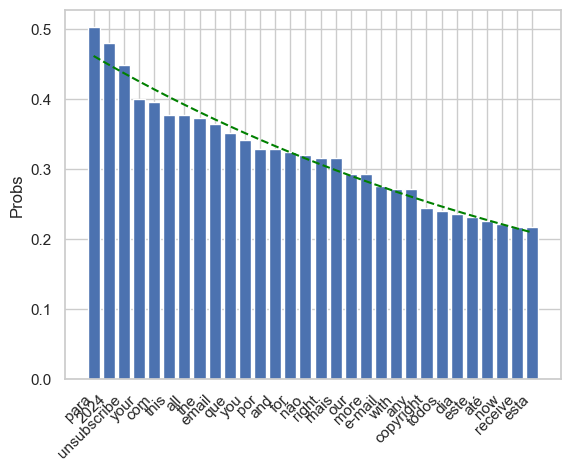

In [196]:
spam_vocab = clf.get_spam_vocab(30)
print(f'{spam_vocab}')

plot_vocab(spam_vocab)

[('email', 0.7777777777777778), ('2024', 0.6481481481481481), ('para', 0.6234567901234568), ('que', 0.5802469135802469), ('receber', 0.4691358024691358), ('com', 0.4506172839506173), ('este', 0.42592592592592593), ('your', 0.4074074074074074), ('uma', 0.4074074074074074), ('teu', 0.4074074074074074), ('por', 0.4074074074074074), ('this', 0.3950617283950617), ('olá', 0.3888888888888889), ('dia', 0.3888888888888889), ('mais', 0.3333333333333333), ('link', 0.3148148148148148), ('porque', 0.30246913580246915), ('não', 0.30246913580246915), ('100', 0.2962962962962963), ('programa', 0.2839506172839506), ('and', 0.2839506172839506), ('podes', 0.2777777777777778), ('tuas', 0.2716049382716049), ('all', 0.2716049382716049), ('via', 0.2654320987654321), ('silva', 0.2654320987654321), ('estás', 0.2654320987654321), ('send', 0.25308641975308643), ('only', 0.25308641975308643), ('meta', 0.25308641975308643)]


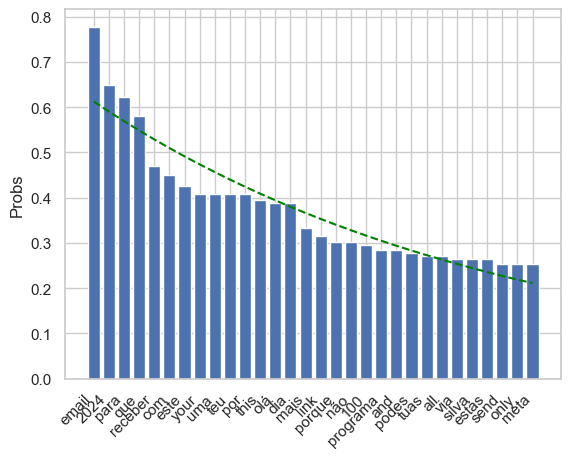

In [197]:
ham_vocab = clf.get_ham_vocab(30)
print(f'{ham_vocab}')

plot_vocab(ham_vocab)

#### Helper Functions for the Logistic Regression Class

In [198]:
def logistic(r):
    return 1 / (1 + jnp.exp(-r))

def predict(c, w, X):
    return logistic(jnp.dot(X, w) + c)

def cost(c, w, X, y, eps=1e-14, lmbd=0.1):
    n = y.size
    p = predict(c, w, X)
    p = jnp.clip(p, eps, 1 - eps)  # bound the probabilities within (0,1) to avoid ln(0)
    return -jnp.sum(y * jnp.log(p) + (1 - y) * jnp.log(1 - p)) / n + 0.5 * lmbd * (jnp.dot(w, w) + c * c)

### Logistic Regression Class

In [199]:
class LR:
    def fit(self, X, y, n_iter = 1000, eta = 5e-2, tol = 1e-6):
        w = 1.0e-5 * jnp.ones(X.shape[1])
        c = 1.0
        new_cost = float(cost(c, w, X, y))
        cost_hist = [new_cost]
        for i in range(n_iter):
            c_current = c
            c -= eta * grad(cost, argnums=0)(c_current, w, X, y)
            w -= eta * grad(cost, argnums=1)(c_current, w, X, y)
            new_cost = float(cost(c, w, X, y))
            cost_hist.append(new_cost)
            if (i > 20) and (i % 10 == 0):
                if jnp.abs(cost_hist[-1] - cost_hist[-20]) < tol:
                    #print(f"Exited loop at iteration {i}")
                    break
        self.c = c
        self.w = w
        self.cost_hist = cost_hist
    
    def get_cost_hist(self):
        return self.cost_hist

    def LR_predict(self, X):
        y_pred_proba = predict(self.c, self.w, X)
        y_pred = jnp.array(y_pred_proba)
        y_pred = jnp.where(y_pred < 0.5, y_pred, 1.0)
        y_pred = jnp.where(y_pred >= 0.5, y_pred, 0.0)
        return y_pred

### Dividing, Training and Evaluation of the Logistic Regression Model

In [200]:
dataset = content_dataset 
X = dataset['content'].tolist() 
y = jnp.array([0 if label == 'ham' else 1 for label in dataset['ham or spam']])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)

tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts).toarray()
X_test_tfidf = tfidf_transformer.transform(X_test_counts).toarray()

clf = LR()
clf.fit(X_train_tfidf, y_train)


y_pred = clf.LR_predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.34      0.51        32
           1       0.68      1.00      0.81        45

    accuracy                           0.73        77
   macro avg       0.84      0.67      0.66        77
weighted avg       0.81      0.73      0.69        77



In [201]:
def _nltk_pos_tagger(nltk_tag):
    if nltk_tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif nltk_tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:          
        return None


def _nltk_pos_lemmatizer(lemmatizer, token, tag):
    if tag is None:
        return lemmatizer.lemmatize(token)
    else:        
        return lemmatizer.lemmatize(token, tag)


def text_pre_processing(txt, m=2):
    if txt is not None:
        lemmatizer = WordNetLemmatizer()
        stop_words = set(nltk.corpus.stopwords.words('english'))

        tokens = nltk.word_tokenize(txt)
        tokens = [w for w in tokens if w.isalpha()]
        tokens = nltk.pos_tag(tokens)
        tokens = [(t[0], _nltk_pos_tagger(t[1])) for t in tokens]
        tokens = [_nltk_pos_lemmatizer(lemmatizer, w, t).lower() for w,t in tokens]
        tokens = [w for w in tokens if len(w) > m]
        tokens = [w for w in tokens if w not in stop_words]
    else:
        tokens = []
    return tokens

In [202]:
dataset = content_dataset 

corpus = dataset['content'].tolist()
y = dataset['ham or spam'].tolist() 

# Preprocess the text
tokens_clean = [text_pre_processing(text) for text in corpus]
tokens_merge = [' '.join(line) for line in tokens_clean]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(tokens_merge, y, stratify=y, test_size=0.2, random_state=42)
    
print(f'Training Data : {len(X_train)}')
print(f'Testing Data  : {len(X_test)}')


Training Data : 306
Testing Data  : 77


In [203]:
# train Bag of Words model
cv = CountVectorizer(ngram_range = (1, 2), max_features=1024)
X_train_cv = cv.fit_transform(X_train)
print(f'Training Data CV : {X_train_cv.shape}')

# transform X_test using CV
X_test_cv = cv.transform(X_test)
print(f'Test Data CV : {X_test_cv.shape}')

# Save the vectorizer to a file
joblib.dump(cv, 'vectorizer.pkl')


Training Data CV : (306, 1024)
Test Data CV : (77, 1024)


['vectorizer.pkl']

In [204]:
clfs = [
    ('LR', LogisticRegression(random_state=42, max_iter=600)),
    ('KNN', KNeighborsClassifier(n_neighbors=1)),
    ('NB', GaussianNB()),
    ('RFC', RandomForestClassifier(random_state=42)),
    ('MLP', MLPClassifier(random_state=42, learning_rate='adaptive', max_iter=1000))
]

#Track the best model and accuracy
best_model = None
best_accuracy = 0.0
best_label = ""

#Train and evaluate models
with joblib.parallel_backend('loky', n_jobs=-1):
    for label, clf in clfs:
        # Train the model
        clf.fit(X_train_cv.toarray(), y_train)

        # Generate predictions
        predictions = clf.predict(X_test_cv.toarray())

        # Compute performance metrics
        acc = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions, average='weighted')
        mcc = matthews_corrcoef(y_test, predictions)

        print(f'{label:3} Accuracy: {acc:.2f}, F1-Score: {f1:.2f}, MCC: {mcc:.2f}')

#Check if this model is the best so far
        if acc > best_accuracy:
            best_accuracy = acc
            best_model = clf
            best_label = label

#Save the best model to a file
if best_model:
    joblib.dump(best_model, 'content_model.pkl')
    print(f"The best model ({best_label}) was saved with accuracy {best_accuracy:.2f}.")

LR  Accuracy: 0.90, F1-Score: 0.90, MCC: 0.79
KNN Accuracy: 0.87, F1-Score: 0.87, MCC: 0.73
NB  Accuracy: 0.92, F1-Score: 0.92, MCC: 0.84
RFC Accuracy: 0.94, F1-Score: 0.93, MCC: 0.87
MLP Accuracy: 0.92, F1-Score: 0.92, MCC: 0.84
The best model (RFC) was saved with accuracy 0.94.


Useful Links:  
https://github.com/HanyMedhat10/Spam-Emails-Classify-ML/blob/main/main.ipynb  
https://www.geeksforgeeks.org/detecting-spam-emails-using-tensorflow-in-python/  
https://www.geeksforgeeks.org/implementing-web-scraping-python-beautiful-soup/  
https://medium.com/analytics-vidhya/spam-email-detector-73518ba46340  
https://www.geeksforgeeks.org/ml-one-hot-encoding/  
https://www.geeksforgeeks.org/saving-a-machine-learning-model/